# LSTM 单栋建筑负荷预测

单步预测过去24h全特征 -> 未来1h负荷

In [1]:
import os
import random
from contextlib import nullcontext
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
import joblib

In [2]:
SEED = 42 # 随机种子
# 用过去【窗口长度】预测未来【预测步长】的负荷
LOOKBACK = 24 # 窗口长度
HORIZON = 1 # 预测步长
BATCH_SIZE = 72 # 每次梯度更新使用的样本数
EPOCHS = 50 # 最大训练轮数

# 路径
DATA_DIR = Path('data')
TRAIN_PATH = DATA_DIR / 'train_std.csv'
VAL_PATH = DATA_DIR / 'val_std.csv'
SCALER_DIR = DATA_DIR / 'scalers'
MODEL_DIR = Path('models')
MODEL_PATH = MODEL_DIR / 'lstm_single_step.pt'

# 列名
TARGET_COL = 'hourly_kwh_clean'
TIME_COL = 'timestamp'

plt.style.use('default')

In [3]:
# 设置随机种子
def set_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# 数据读取
def load_data(path: Path, time_col: str = TIME_COL) -> pd.DataFrame:
    df = pd.read_csv(path)
    df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
    df = df.dropna(subset=[time_col]).sort_values(time_col).reset_index(drop=True)
    return df

# 滑动窗口构造
def create_sequences(df: pd.DataFrame, feature_cols, target_col: str, lookback: int = 24, horizon: int = 1, time_col: str = TIME_COL):
    values = df[feature_cols].astype(np.float32).to_numpy()
    target_idx = feature_cols.index(target_col)

    x, y = [], []
    max_i = len(df) - lookback - horizon + 1
    for i in range(max_i):
        ts_seg = df[time_col].iloc[i:i + lookback + horizon]
        if ts_seg.isna().any():
            continue # 如有缺失值跳过
        if not (ts_seg.diff().dropna() == pd.Timedelta(hours=1)).all():
            continue # 如有间断点跳过

        x_i = values[i:i + lookback] # 输入窗口
        y_i = values[i + lookback + horizon - 1, target_idx] # 输出标签
        if np.isnan(x_i).any() or np.isnan(y_i):
            continue # 如有缺失值跳过

        x.append(x_i)
        y.append(y_i)

    return np.array(x, dtype=np.float32), np.array(y, dtype=np.float32)

# 计算MAPE
def mape(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    denom = np.where(np.abs(y_true) < eps, eps, np.abs(y_true)) # 防止分母为零
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

# 计算性能评估指标
def evaluate(y_true_std, y_pred_std, scaler):
    y_true = scaler.inverse_transform(y_true_std.reshape(-1, 1)).ravel()
    y_pred = scaler.inverse_transform(y_pred_std.reshape(-1, 1)).ravel()

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_value = mape(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape_value, 'R2': r2}

# PyTorch Dataset
class LoadDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y).unsqueeze(-1)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# LSTM模型
class LSTMPredictor(nn.Module):
    def __init__(self, input_size, hidden_size=128):
        super(LSTMPredictor, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.activation = nn.SELU()  # SELU激活函数
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        # x shape: (batch, seq_len, features)
        lstm_out, (h_n, c_n) = self.lstm(x)
        # 取最后一个时间步的输出
        out = lstm_out[:, -1, :]
        out = self.activation(out)
        out = self.fc(out)
        return out

# 训练函数
# optimizer=None时为验证函数
def run_epoch(model, dataloader, criterion, device, optimizer=None):
    model.train() if optimizer else model.eval()
    total_loss = 0
    
    context = torch.no_grad() if optimizer is None else nullcontext()
    with context:
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            if optimizer:
                optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            if optimizer:
                loss.backward()
                optimizer.step()
            
            total_loss += loss.item() * X_batch.size(0)
    
    return total_loss / len(dataloader.dataset)

# 预测函数
def predict(model, dataloader, device):
    model.eval()
    predictions = []
    with torch.no_grad():
        for X_batch, _ in dataloader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            predictions.append(outputs.cpu().numpy())
    return np.concatenate(predictions, axis=0).ravel()

# 早停类
class EarlyStopping:
    def __init__(self, patience=8, min_delta=0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_weights = None
        self.best_loss = float('inf')
        self.counter = 0
        self.early_stop = False
    
    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            if self.restore_best_weights:
                self.best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        
        return self.early_stop
    
    def restore(self, model):
        if self.best_weights is not None:
            model.load_state_dict(self.best_weights)

# 绘制训练 loss 曲线（标准化尺度）
def plot_training_history(train_losses, val_losses):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.grid(True, alpha=0.3)
    ax.plot(train_losses, label='Train MAE', color='tab:blue')
    ax.plot(val_losses, label='Val MAE', color='tab:orange')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MAE')
    ax.set_title('Training and Validation Loss')
    ax.legend(facecolor='white', edgecolor='black', labelcolor='black')
    plt.tight_layout()
    plt.show()

# 绘制预测结果对比
def plot_predictions(y_true, y_pred, title, scaler=None):
    y_true = scaler.inverse_transform(y_true.reshape(-1, 1)).ravel()
    y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1)).ravel()
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.grid(True, alpha=0.3)
    ax.plot(y_true, label='Real', color='tab:blue')
    ax.plot(y_pred, label='Predict', color='tab:orange')
    ax.set_xlabel('Sample')
    ax.set_ylabel('kWh')
    ax.set_title(title)
    ax.legend(facecolor='white', edgecolor='black', labelcolor='black')
    plt.tight_layout()
    plt.show()

In [4]:
set_seed(SEED)

# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 读取已标准化数据
train_df = load_data(TRAIN_PATH).dropna(subset=[TARGET_COL]).reset_index(drop=True)
val_df = load_data(VAL_PATH).dropna(subset=[TARGET_COL]).reset_index(drop=True)

# 保留全特征（除时间列）
FEATURE_COLS = [c for c in train_df.columns if c != TIME_COL]

# 构造序列
X_train, y_train = create_sequences(train_df, FEATURE_COLS, TARGET_COL, LOOKBACK, HORIZON, TIME_COL)
X_val, y_val = create_sequences(val_df, FEATURE_COLS, TARGET_COL, LOOKBACK, HORIZON, TIME_COL)

In [5]:
# 创建数据加载器
train_dataset = LoadDataset(X_train, y_train)
val_dataset = LoadDataset(X_val, y_val)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 创建模型
input_size = X_train.shape[2]  # 特征维度
model_base = LSTMPredictor(input_size=input_size, hidden_size=128)
model_base = model_base.to(device)

# 损失函数和优化器
# weight_decay=1e-3 防止过拟合
criterion = nn.L1Loss()  # MAE loss
optimizer = torch.optim.Adam(model_base.parameters(), weight_decay=1e-3)

# 回调函数
# patience=5 更早停止防止过拟合
early_stopping = EarlyStopping(patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=4, min_lr=1e-5)

# 训练记录
train_losses = []
val_losses = []
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    train_loss = run_epoch(model_base, train_loader, criterion, device, optimizer)
    val_loss = run_epoch(model_base, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    # 更新学习率
    lr_scheduler.step(val_loss)
    
    # 保存最佳模型
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_base.state_dict(), MODEL_PATH)
    
    # 早停检查
    if early_stopping(val_loss, model_base):
        break

# 恢复最佳权重
early_stopping.restore(model_base)

# 输出训练信息
actual_epochs = len(train_losses)
print(f"训练完成，共 {actual_epochs} 个 epoch")
print(f"最佳 val_loss={best_val_loss:.6f}")

训练完成，共 24 个 epoch
最佳 val_loss=0.117507


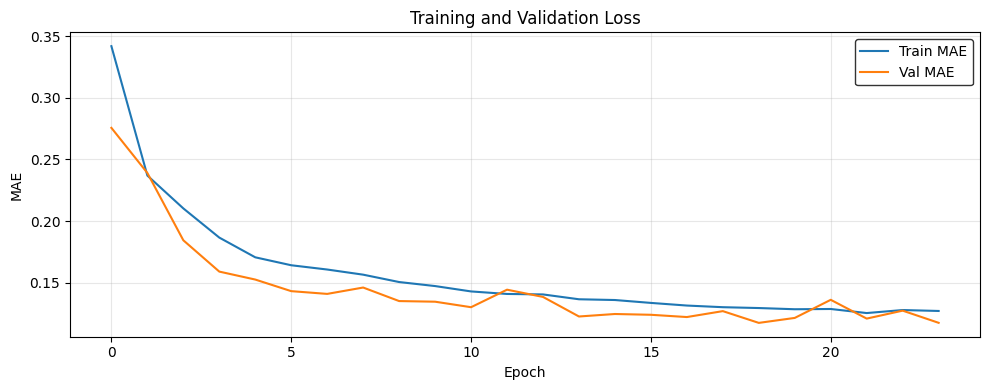

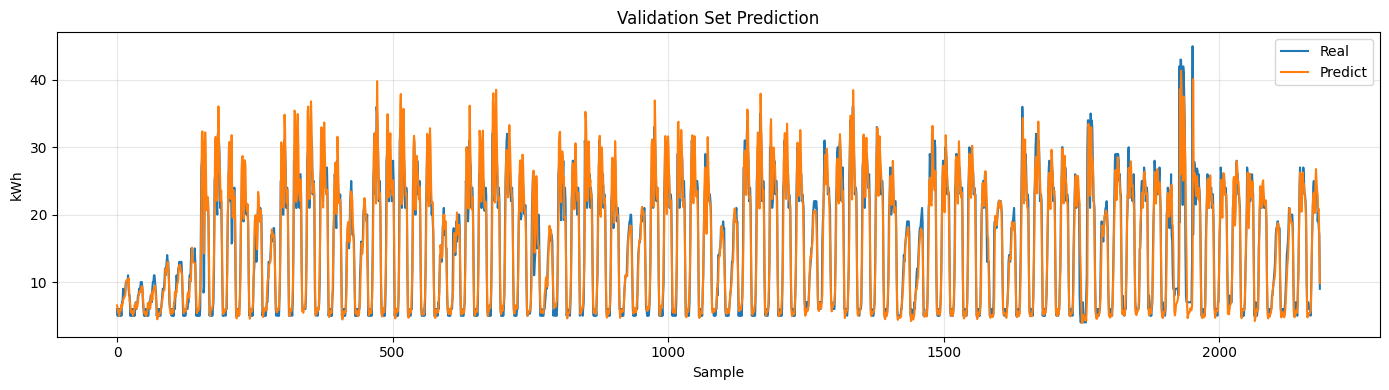

In [6]:
# 预测
y_pred_val = predict(model_base, val_loader, device)

# 原始尺度评估
inverse_scaler: StandardScaler = joblib.load(SCALER_DIR / 'load_scaler.joblib')
metrics_base = evaluate(y_val, y_pred_val, inverse_scaler)

# 可视化训练过程中的 loss 曲线（标准化尺度）
plot_training_history(train_losses, val_losses)

# 可视化预测结果对比
plot_predictions(y_val, y_pred_val, title="Validation Set Prediction", scaler=inverse_scaler)

In [7]:
# 验证集前70%微调，后30%评估
split_idx = int(len(X_val) * 0.7)
X_tune, y_tune = X_val[:split_idx], y_val[:split_idx]
X_test_tail, y_test_tail = X_val[split_idx:], y_val[split_idx:]

# 创建微调数据加载器
tune_dataset = LoadDataset(X_tune, y_tune)
test_tail_dataset = LoadDataset(X_test_tail, y_test_tail)
tune_loader = DataLoader(tune_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_tail_loader = DataLoader(test_tail_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 复制模型进行微调
model_ft = LSTMPredictor(input_size=input_size, hidden_size=128)
model_ft.load_state_dict(model_base.state_dict())
model_ft = model_ft.to(device)

# 优化后的微调参数
# - 学习率：1e-4（避免过快遗忘）
# - 早停耐心：5（允许充分训练）
# - 权重衰减：1e-3（防止过拟合）
# - 学习率调度器：ReduceLROnPlateau（自适应降低学习率）
optimizer_ft = torch.optim.Adam(model_ft.parameters(), lr=1e-4, weight_decay=1e-3)
lr_scheduler_ft = ReduceLROnPlateau(optimizer_ft, factor=0.5, patience=3, min_lr=1e-6)
early_stopping_ft = EarlyStopping(patience=5, restore_best_weights=True)

train_losses_ft = []
val_losses_ft = []

for epoch in range(EPOCHS):
    train_loss = run_epoch(model_ft, tune_loader, criterion, device, optimizer_ft)
    val_loss = run_epoch(model_ft, test_tail_loader, criterion, device)
    
    train_losses_ft.append(train_loss)
    val_losses_ft.append(val_loss)
    
    # 更新学习率
    lr_scheduler_ft.step(val_loss)
    
    if early_stopping_ft(val_loss, model_ft):
        break

early_stopping_ft.restore(model_ft)
print(f"Fine-tuning completed in {len(train_losses_ft)} epochs")

Fine-tuning completed in 13 epochs


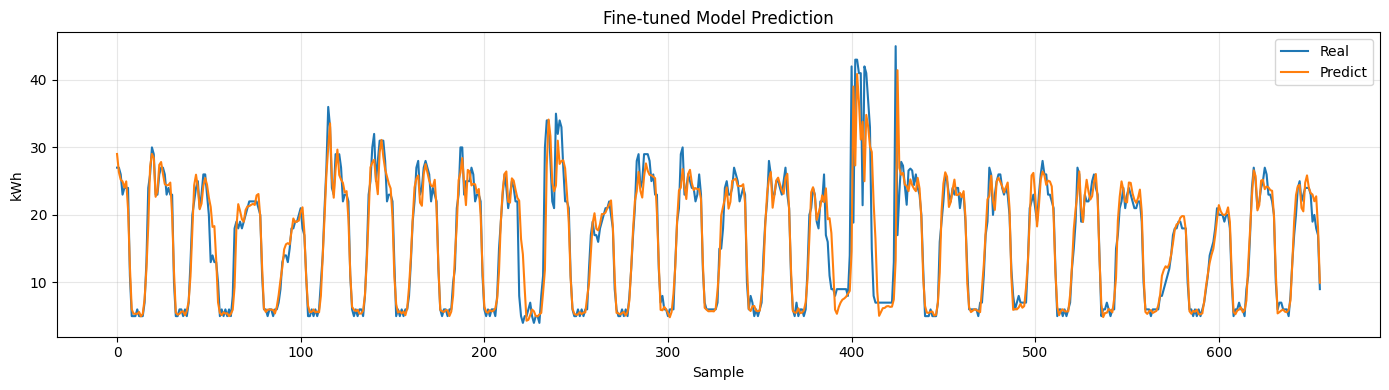

In [8]:
y_pred_ft = predict(model_ft, test_tail_loader, device)
metrics_ft = evaluate(y_test_tail, y_pred_ft, inverse_scaler)

y_pred_base_test = predict(model_base, test_tail_loader, device)
metrics_base_test = evaluate(y_test_tail, y_pred_base_test, inverse_scaler)

# 可视化微调后预测结果对比
plot_predictions(y_test_tail, y_pred_ft, title="Fine-tuned Model Prediction", scaler=inverse_scaler)

In [9]:
# 结果对比汇总
summary = pd.DataFrame([
    {'Model': 'Base (full val set)', **metrics_base},
    {'Model': 'Base (test set only)', **metrics_base_test},
    {'Model': 'Fine-tuned', **metrics_ft},
])
summary

,Model,MAE,RMSE,MAPE,R2
0,Base (full val set),1.727221,2.750969,12.287248,0.906504
1,Base (test set only),1.837213,3.392519,12.997031,0.856625
2,Fine-tuned,1.698752,3.291753,12.247562,0.865016
